In [1]:
# ================================================================
# CELL 01 — IMPORT & SETTINGS
# ================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine, text
import warnings

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)

# Style biểu đồ — tối giản
plt.rcParams.update({
    "figure.dpi"       : 110,
    "axes.spines.top"  : False,
    "axes.spines.right": False,
    "axes.titlesize"   : 12,
    "axes.titleweight" : "bold",
    "axes.labelsize"   : 10,
    "figure.figsize"   : (10, 4),
})

print("✅ Import xong")

✅ Import xong


In [ ]:
# ================================================================
# CELL 02 — KẾT NỐI DATABASE
# ================================================================
from utils.config import DB_CONFIG

# ── HÀM TÁI SỬ DỤNG ────────────────────────────────────────────
def make_engine(cfg: dict):
    """Tạo kết nối SQLAlchemy từ dict config."""
    conn_str = (
        f"mysql+pymysql://{cfg['user']}:{cfg['password']}"
        f"@{cfg['host']}:{cfg['port']}/{cfg['database']}"
    )
    return create_engine(conn_str, pool_recycle=3600)


engine = make_engine(DB_CONFIG)

# Kiểm tra kết nối
with engine.connect() as conn:
    ver = conn.execute(text("SELECT VERSION()")).fetchone()[0]

print(f"✅ Kết nối thành công")
print(f"   MySQL version: {ver}")

✅ Kết nối thành công
   MySQL version: 8.0.46


In [3]:
# ================================================================
# CELL 03 — LẤY DỮ LIỆU BẰNG SQL
# ================================================================

query = """
SELECT
    o.orderNumber,
    o.orderDate,
    o.shippedDate,
    o.status         AS orderStatus,

    c.customerNumber,
    c.customerName,
    c.country        AS customerCountry,
    c.city           AS customerCity,
    c.creditLimit,

    CONCAT(e.firstName, ' ', e.lastName) AS salesRep,

    p.productName,
    p.productLine,
    p.quantityInStock,

    od.quantityOrdered,
    od.priceEach,

    (od.quantityOrdered * od.priceEach)  AS lineRevenue

FROM orderdetails od
JOIN orders      o  ON od.orderNumber   = o.orderNumber
JOIN customers   c  ON o.customerNumber = c.customerNumber
JOIN employees   e  ON c.salesRepEmployeeNumber = e.employeeNumber
JOIN products    p  ON od.productCode   = p.productCode
"""

df = pd.read_sql(
    query, engine,
    parse_dates=["orderDate", "shippedDate"]
)

print(f"✅ Đọc dữ liệu xong")
print(f"   Số dòng : {df.shape[0]:,}")
print(f"   Số cột  : {df.shape[1]}")
print()
print(df.dtypes.to_string())

✅ Đọc dữ liệu xong
   Số dòng : 2,996
   Số cột  : 16

orderNumber                int64
orderDate          datetime64[s]
shippedDate        datetime64[s]
orderStatus                  str
customerNumber             int64
customerName                 str
customerCountry              str
customerCity                 str
creditLimit              float64
salesRep                     str
productName                  str
productLine                  str
quantityInStock            int64
quantityOrdered            int64
priceEach                float64
lineRevenue              float64


In [4]:
# ================================================================
# CELL 04 — TỐI ƯU RAM
# ================================================================

# ── HÀM TÁI SỬ DỤNG ────────────────────────────────────────────
def optimize_dtypes(df: pd.DataFrame) -> pd.DataFrame:
    """
    Tự động giảm RAM bằng cách:
    - Downcast số nguyên (int64 → int16/int32)
    - Downcast số thực (float64 → float32)
    - Chuyển chuỗi ít giá trị duy nhất sang category
    """
    out = df.copy()
    for col in out.columns:
        t = out[col].dtype
        if t in ["int64", "int32"]:
            vmin, vmax = out[col].min(), out[col].max()
            for itype in [np.int8, np.int16, np.int32]:
                if vmin >= np.iinfo(itype).min and vmax <= np.iinfo(itype).max:
                    out[col] = out[col].astype(itype)
                    break
        elif t == "float64":
            out[col] = out[col].astype(np.float32)
        elif t == "str":
            if out[col].nunique() / len(out) < 0.5:
                out[col] = out[col].astype("category")
    return out


mb_before = df.memory_usage(deep=True).sum() / 1024**2
df        = optimize_dtypes(df)
mb_after  = df.memory_usage(deep=True).sum() / 1024**2

print(f"RAM trước : {mb_before:.2f} MB")
print(f"RAM sau   : {mb_after:.2f} MB")
print(f"Tiết kiệm : {(1 - mb_after/mb_before)*100:.0f}%")

RAM trước : 0.62 MB
RAM sau   : 0.13 MB
Tiết kiệm : 79%


In [5]:
# ================================================================
# CELL 05 — TỔNG QUAN DỮ LIỆU
# ================================================================

print("=== THÔNG TIN TỔNG QUAN ===")
print(f"Số dòng  : {df.shape[0]:,}")
print(f"Số cột   : {df.shape[1]}")
print(f"Từ ngày  : {df['orderDate'].min().date()}")
print(f"Đến ngày : {df['orderDate'].max().date()}")
print()
print("--- 5 dòng đầu ---")
print(df.head().to_string())
print()
print("--- 5 dòng ngẫu nhiên ---")
print(df.sample(5, random_state=42).to_string())

=== THÔNG TIN TỔNG QUAN ===
Số dòng  : 2,996
Số cột   : 16
Từ ngày  : 2003-01-06
Đến ngày : 2005-05-31

--- 5 dòng đầu ---
   orderNumber  orderDate shippedDate orderStatus  customerNumber                  customerName customerCountry customerCity  creditLimit         salesRep                          productName   productLine  quantityInStock  quantityOrdered  priceEach  lineRevenue
0        10100 2003-01-06  2003-01-10     Shipped             363  Online Diecast Creations Co.             USA       Nashua   114,200.00  Steve Patterson             1917 Grand Touring Sedan  Vintage Cars             2724               30     136.00     4,080.00
1        10100 2003-01-06  2003-01-10     Shipped             363  Online Diecast Creations Co.             USA       Nashua   114,200.00  Steve Patterson                   1911 Ford Town Car  Vintage Cars              540               50      55.09     2,754.50
2        10100 2003-01-06  2003-01-10     Shipped             363  Online Diecast Cre

In [6]:
# ================================================================
# CELL 06 — BÁO CÁO CHẤT LƯỢNG DỮ LIỆU
# ================================================================

# ── HÀM TÁI SỬ DỤNG ────────────────────────────────────────────
def quality_report(df: pd.DataFrame) -> pd.DataFrame:
    """
    Báo cáo nhanh chất lượng từng cột:
    kiểu dữ liệu, số missing, số unique, giá trị mẫu.
    """
    rows = []
    for col in df.columns:
        s      = df[col]
        n_miss = s.isnull().sum()
        rows.append({
            "Cột"       : col,
            "Kiểu"      : str(s.dtype),
            "Missing"   : n_miss,
            "Missing%"  : f"{n_miss/len(s)*100:.1f}%",
            "Unique"    : s.nunique(),
            "Mẫu"       : s.dropna().iloc[0] if n_miss < len(s) else "ALL NULL",
        })
    return pd.DataFrame(rows).set_index("Cột")


qr = quality_report(df)
print(qr.to_string())

                          Kiểu  Missing Missing%  Unique                           Mẫu
Cột                                                                                   
orderNumber              int16        0     0.0%     326                         10100
orderDate        datetime64[s]        0     0.0%     265           2003-01-06 00:00:00
shippedDate      datetime64[s]      141     4.7%     247           2003-01-10 00:00:00
orderStatus           category        0     0.0%       6                       Shipped
customerNumber           int16        0     0.0%      98                           363
customerName          category        0     0.0%      98  Online Diecast Creations Co.
customerCountry       category        0     0.0%      22                           USA
customerCity          category        0     0.0%      78                        Nashua
creditLimit            float32        0     0.0%      92                    114,200.00
salesRep              category        0    

In [7]:
# ================================================================
# CELL 07 — XỬ LÝ MISSING VALUES
# ================================================================

# Xem missing của từng cột
missing = df.isnull().sum()
missing = missing[missing > 0]

print("=== CỘT CÓ MISSING ===")
for col, n in missing.items():
    pct = n / len(df) * 100
    print(f"  {col:<15}: {n:>4} dòng ({pct:.1f}%)")

print()

# shippedDate NULL → Đơn chưa giao → Tạo flag thay vì xóa
df["isShipped"]    = df["shippedDate"].notna().astype(int)
df["deliveryDays"] = (df["shippedDate"] - df["orderDate"]).dt.days
df["deliveryDays"] = df["deliveryDays"].fillna(-1).astype(int)

print("=== SAU XỬ LÝ ===")
print(f"  isShipped = 1 (đã giao) : {df['isShipped'].sum():,} dòng")
print(f"  isShipped = 0 (chưa giao): {(df['isShipped']==0).sum():,} dòng")
print(f"  Thời gian giao TB        : "
      f"{df[df['deliveryDays']>0]['deliveryDays'].mean():.1f} ngày")
print()
print(f"  Missing còn lại: {df.isnull().sum().sum()} ✅")

=== CỘT CÓ MISSING ===
  shippedDate    :  141 dòng (4.7%)

=== SAU XỬ LÝ ===
  isShipped = 1 (đã giao) : 2,855 dòng
  isShipped = 0 (chưa giao): 141 dòng
  Thời gian giao TB        : 3.9 ngày

  Missing còn lại: 141 ✅


In [9]:
# ================================================================
# CELL 08 — DUPLICATE & LOGIC CHECK
# ================================================================

# ── HÀM TÁI SỬ DỤNG ────────────────────────────────────────────
def check_duplicates(df: pd.DataFrame,
                     key_cols: list = None) -> None:
    """
    Kiểm tra duplicate toàn phần và theo khóa chính.
    
    Parameters
    ----------
    df       : DataFrame cần kiểm tra
    key_cols : List cột làm khóa chính (ví dụ: ['orderNumber','productName'])
               Nếu None → Chỉ kiểm tra duplicate toàn phần
    """
    print("=== KIỂM TRA DUPLICATE ===")

    # Duplicate toàn phần
    n_full = df.duplicated().sum()
    print(f"  Duplicate toàn phần          : {n_full} dòng  "
          f"{'✅ OK' if n_full == 0 else '⚠️  Cần xử lý'}")

    # Duplicate theo khóa chính
    if key_cols:
        n_key = df.duplicated(subset=key_cols).sum()
        print(f"  Duplicate theo {key_cols}")
        print(f"                               : {n_key} dòng  "
              f"{'✅ OK' if n_key == 0 else '⚠️  Cần xử lý'}")

        # Hiển thị chi tiết nếu có duplicate
        if n_key > 0:
            dup_rows = df[df.duplicated(subset=key_cols, keep=False)]
            print(f"\n  Chi tiết {n_key} dòng duplicate:")
            print(dup_rows.sort_values(key_cols)
                          .head(10)
                          .to_string(index=False))


def check_data_issues(df: pd.DataFrame, checks: dict) -> None:
    """
    Kiểm tra các điều kiện logic.
    checks = {"tên kiểm tra": điều_kiện_boolean}
    """
    print("\n=== KIỂM TRA LOGIC ===")
    for name, condition in checks.items():
        n      = int(condition.sum())
        status = "✅ OK" if n == 0 else f"⚠️  {n} dòng vi phạm"
        print(f"  {name:<30}: {status}")


# ── Áp dụng ─────────────────────────────────────────────────────
check_duplicates(df, key_cols=["orderNumber", "productName"])

checks = {
    "lineRevenue <= 0"    : df["lineRevenue"]     <= 0,
    "quantityOrdered <= 0": df["quantityOrdered"] <= 0,
    "priceEach <= 0"      : df["priceEach"]       <= 0,
    "creditLimit < 0"     : df["creditLimit"]     < 0,
}

check_data_issues(df, checks)

=== KIỂM TRA DUPLICATE ===
  Duplicate toàn phần          : 0 dòng  ✅ OK
  Duplicate theo ['orderNumber', 'productName']
                               : 0 dòng  ✅ OK

=== KIỂM TRA LOGIC ===
  lineRevenue <= 0              : ✅ OK
  quantityOrdered <= 0          : ✅ OK
  priceEach <= 0                : ✅ OK
  creditLimit < 0               : ✅ OK


In [10]:

# ================================================================
# CELL 09 — THỐNG KÊ MÔ TẢ
# ================================================================

def describe_all(df: pd.DataFrame) -> None:
    """
    Thống kê mô tả chia theo từng kiểu dữ liệu.
    - Số (int, float) : count, mean, std, min, max, percentiles
    - Phân loại (object, category) : count, unique, top, freq
    - Thời gian (datetime) : count, min, max
    """

    # ── Số ──────────────────────────────────────────────────────
    num_df = df.select_dtypes(include=["number"])
    if not num_df.empty:
        print("=== BIẾN SỐ (numeric) ===")
        print(num_df.describe().round(2).to_string())

    # ── Phân loại ───────────────────────────────────────────────
    cat_df = df.select_dtypes(include=["object", "category"])
    if not cat_df.empty:
        print("\n=== BIẾN PHÂN LOẠI (object / category) ===")
        print(cat_df.describe().to_string())

    # ── Thời gian ───────────────────────────────────────────────
    dt_df = df.select_dtypes(include=["datetime64[ns]"])
    if not dt_df.empty:
        print("\n=== BIẾN THỜI GIAN (datetime) ===")
        print(dt_df.describe().to_string())


describe_all(df)


=== BIẾN SỐ (numeric) ===
       orderNumber  customerNumber  creditLimit  quantityInStock  quantityOrdered  priceEach  lineRevenue  isShipped  deliveryDays
count     2,996.00        2,996.00     2,996.00         2,996.00         2,996.00   2,996.00     2,996.00   2,996.00      2,996.00
mean     10,260.35          259.68   109,463.08         5,050.08            35.22      90.77     3,205.67       0.95          3.68
std          92.48          118.41    51,542.10         2,925.00             9.83      36.58     1,632.01       0.21          5.15
min      10,100.00          103.00    11,000.00            15.00             6.00      26.55       481.50       0.00         -1.00
25%      10,181.00          145.00    77,700.00         2,378.00            27.00      62.00     1,990.28       1.00          2.00
50%      10,262.00          240.00    95,000.00         5,437.50            35.00      85.81     2,880.24       1.00          3.00
75%      10,338.25          353.00   119,600.00         7

In [11]:
# ================================================================
# CELL 10 — HÀM VISUAL TÁI SỬ DỤNG
# ================================================================

# ── HÀM 1: Histogram ────────────────────────────────────────────
def plot_histogram(df: pd.DataFrame, col: str, bins: int = 30,
                   title: str = None, color: str = "steelblue"):
    """
    Vẽ histogram cho 1 biến số.
    Thêm đường Mean (đỏ) và Median (xanh lá).
    """
    data   = df[col].dropna()
    mean_v = data.mean()
    med_v  = data.median()

    fig, ax = plt.subplots()
    ax.hist(data, bins=bins, color=color, edgecolor="white", alpha=0.8)
    ax.axvline(mean_v, color="red",   lw=2, linestyle="--",
               label=f"Mean = {mean_v:,.1f}")
    ax.axvline(med_v,  color="green", lw=2, linestyle="-",
               label=f"Median = {med_v:,.1f}")
    ax.set_title(title or col)
    ax.set_xlabel(col)
    ax.set_ylabel("Số dòng")
    ax.legend()
    plt.tight_layout()
    plt.show()


# ── HÀM 2: Bar chart nằm ngang ──────────────────────────────────
def plot_bar(df: pd.DataFrame, col: str, value: str,
             top_n: int = 10, title: str = None,
             color: str = "steelblue"):
    """
    Bar chart nằm ngang: So sánh giá trị theo nhóm.
    col   = cột nhóm (trục Y)
    value = cột giá trị (trục X)
    """
    data = (df.groupby(col)[value]
              .sum()
              .sort_values()
              .tail(top_n))

    fig, ax = plt.subplots()
    ax.barh(data.index.astype(str), data.values,
            color=color, edgecolor="white")
    ax.set_title(title or f"{value} theo {col}")
    ax.set_xlabel(value)
    plt.tight_layout()
    plt.show()


# ── HÀM 3: Count bar ────────────────────────────────────────────
def plot_countbar(df: pd.DataFrame, col: str,
                  title: str = None, color: str = "steelblue"):
    """
    Đếm số lần xuất hiện của từng giá trị trong 1 cột phân loại.
    """
    counts = df[col].value_counts()

    fig, ax = plt.subplots()
    ax.bar(counts.index.astype(str), counts.values,
           color=color, edgecolor="white")
    ax.set_title(title or f"Phân bổ {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Số dòng")
    ax.tick_params(axis="x", rotation=30)
    plt.tight_layout()
    plt.show()


# ── HÀM 4: Boxplot theo nhóm ────────────────────────────────────
def plot_boxplot(df: pd.DataFrame, num_col: str, cat_col: str,
                 title: str = None):
    """
    Boxplot so sánh phân phối 1 biến số theo nhóm phân loại.
    num_col = cột số (trục Y)
    cat_col = cột nhóm (trục X)
    """
    order = (df.groupby(cat_col)[num_col]
               .median()
               .sort_values(ascending=False)
               .index.tolist())

    fig, ax = plt.subplots()
    sns.boxplot(data=df, x=cat_col, y=num_col,
                order=order, palette="tab10", ax=ax,
                flierprops={"marker": ".", "markersize": 4,
                            "markerfacecolor": "gray", "alpha": 0.5})
    ax.set_title(title or f"{num_col} theo {cat_col}")
    ax.set_xlabel(cat_col)
    ax.set_ylabel(num_col)
    ax.tick_params(axis="x", rotation=20)
    plt.tight_layout()
    plt.show()


# ── HÀM 5: Line chart theo thời gian ────────────────────────────
def plot_line(df: pd.DataFrame, date_col: str, value_col: str,
              freq: str = "M", agg: str = "sum",
              title: str = None, color: str = "steelblue"):
    """
    Line chart tổng hợp theo thời gian.
    freq = 'M' (tháng), 'Q' (quý), 'Y' (năm)
    agg  = 'sum', 'mean', 'count'
    """
    ts = (df.set_index(date_col)[value_col]
            .resample(freq)
            .agg(agg))

    fig, ax = plt.subplots()
    ax.plot(ts.index, ts.values, marker="o", ms=4,
            lw=2, color=color)
    ax.fill_between(ts.index, ts.values, alpha=0.1, color=color)
    ax.set_title(title or f"{value_col} theo thời gian")
    ax.set_ylabel(value_col)
    ax.tick_params(axis="x", rotation=30)
    plt.tight_layout()
    plt.show()


# ── HÀM 6: Heatmap tương quan ───────────────────────────────────
def plot_heatmap_corr(df: pd.DataFrame, cols: list,
                       title: str = "Ma trận tương quan"):
    """
    Heatmap tương quan Pearson giữa các biến số.
    Chỉ hiển thị tam giác dưới cho dễ đọc.
    """
    corr = df[cols].corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))

    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(corr, mask=mask, annot=True, fmt=".2f",
                cmap="RdYlGn", vmin=-1, vmax=1, center=0,
                square=True, linewidths=0.5, ax=ax)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()


print("✅ Đã định nghĩa 6 hàm visual")
print("   plot_histogram()    — Phân phối 1 biến số")
print("   plot_bar()          — So sánh tổng/trung bình theo nhóm")
print("   plot_countbar()     — Đếm tần suất biến phân loại")
print("   plot_boxplot()      — Phân phối theo nhóm")
print("   plot_line()         — Xu hướng theo thời gian")
print("   plot_heatmap_corr() — Tương quan các biến số")

✅ Đã định nghĩa 6 hàm visual
   plot_histogram()    — Phân phối 1 biến số
   plot_bar()          — So sánh tổng/trung bình theo nhóm
   plot_countbar()     — Đếm tần suất biến phân loại
   plot_boxplot()      — Phân phối theo nhóm
   plot_line()         — Xu hướng theo thời gian
   plot_heatmap_corr() — Tương quan các biến số


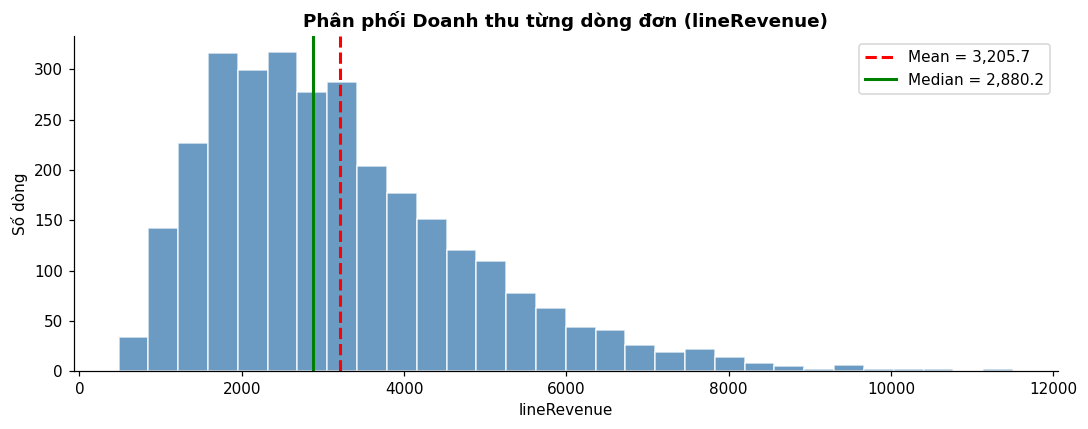

In [12]:
# ================================================================
# CELL 11 — PHÂN TÍCH BIẾN SỐ: lineRevenue
# ================================================================

plot_histogram(df, "lineRevenue",
               title="Phân phối Doanh thu từng dòng đơn (lineRevenue)")

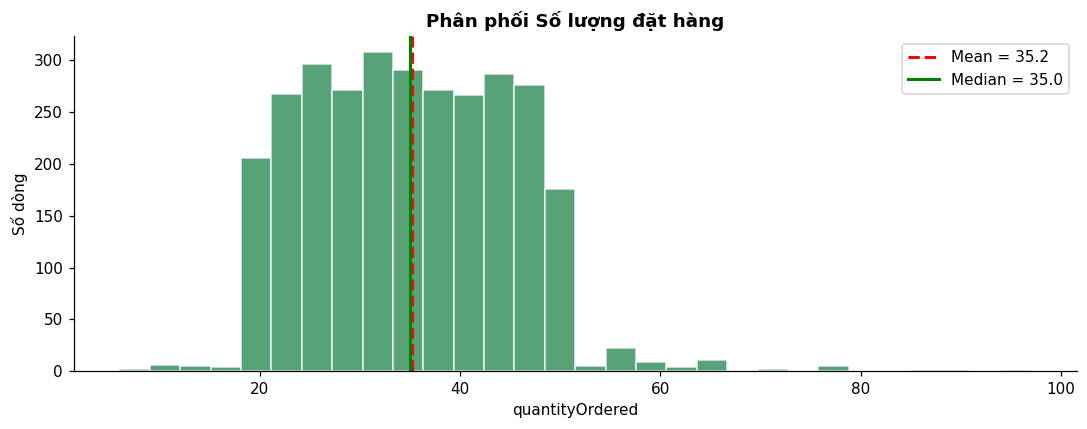

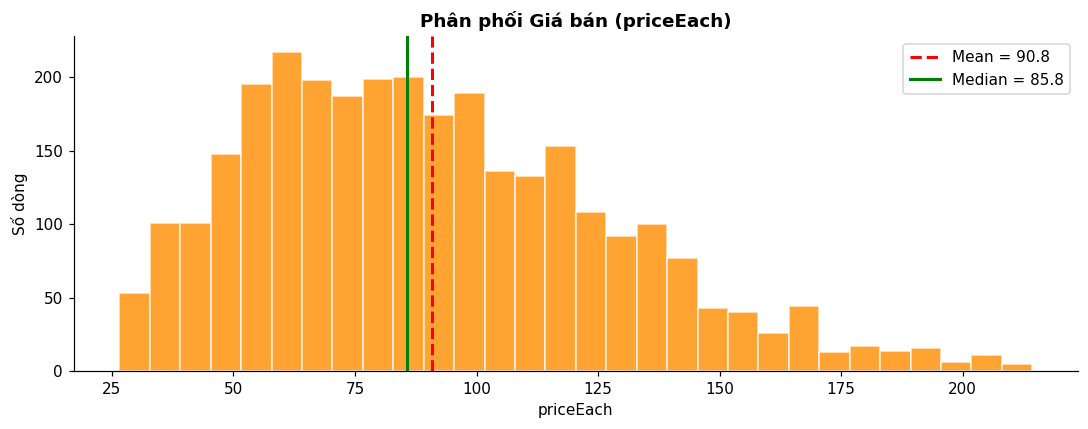

In [13]:
# ================================================================
# CELL 12 — PHÂN TÍCH BIẾN SỐ: quantityOrdered & priceEach
# ================================================================

plot_histogram(df, "quantityOrdered",
               title="Phân phối Số lượng đặt hàng",
               color="seagreen")

plot_histogram(df, "priceEach",
               title="Phân phối Giá bán (priceEach)",
               color="darkorange")

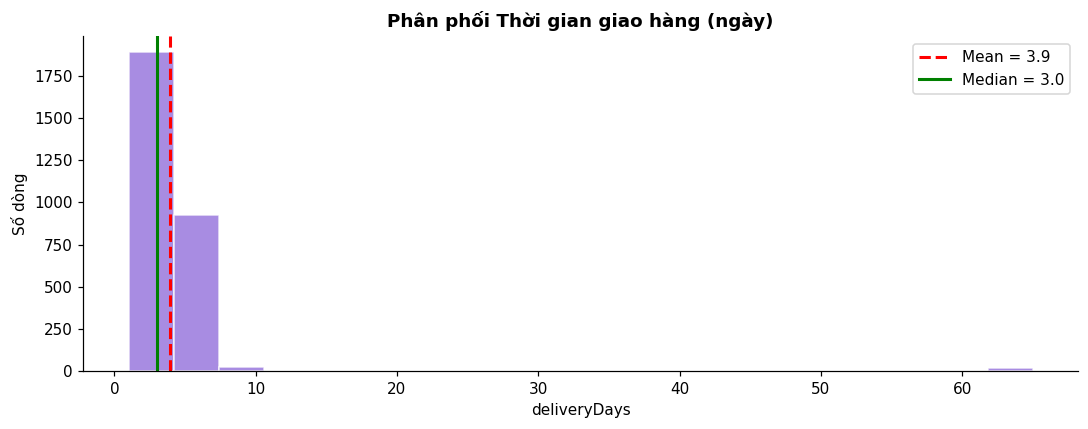

Giao trong 1-3 ngày : 1,435 đơn (50.3%)
Giao trong 4-7 ngày : 1,379 đơn (48.3%)
Giao trên 7 ngày    : 41 đơn (1.4%)


In [14]:
# ================================================================
# CELL 13 — PHÂN TÍCH BIẾN SỐ: deliveryDays
# ================================================================

# Chỉ xét đơn đã giao
df_shipped = df[df["deliveryDays"] > 0].copy()

plot_histogram(df_shipped, "deliveryDays",
               title="Phân phối Thời gian giao hàng (ngày)",
               color="mediumpurple",
               bins=20)

print(f"Giao trong 1-3 ngày : "
      f"{(df_shipped['deliveryDays'] <= 3).sum():,} đơn "
      f"({(df_shipped['deliveryDays'] <= 3).mean()*100:.1f}%)")
print(f"Giao trong 4-7 ngày : "
      f"{((df_shipped['deliveryDays'] > 3) & (df_shipped['deliveryDays'] <= 7)).sum():,} đơn "
      f"({((df_shipped['deliveryDays'] > 3) & (df_shipped['deliveryDays'] <= 7)).mean()*100:.1f}%)")
print(f"Giao trên 7 ngày    : "
      f"{(df_shipped['deliveryDays'] > 7).sum():,} đơn "
      f"({(df_shipped['deliveryDays'] > 7).mean()*100:.1f}%)")

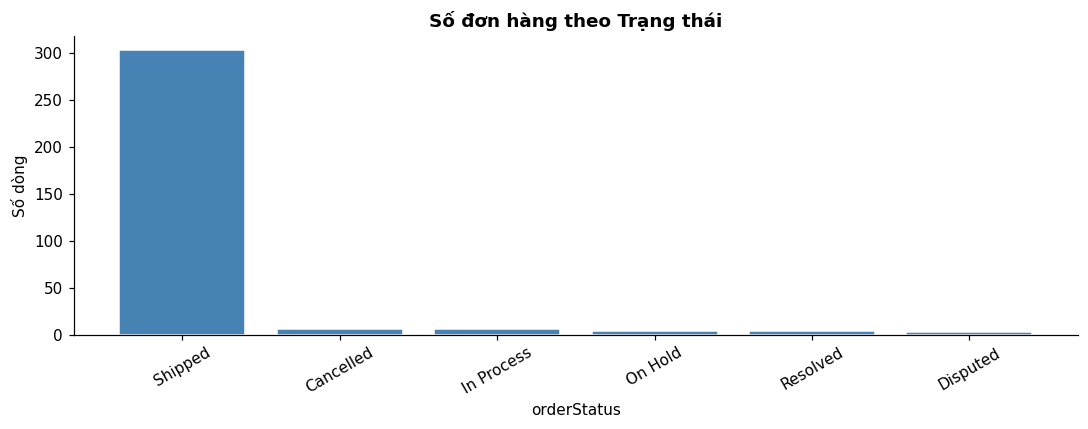

orderStatus
Shipped       303
Cancelled       6
In Process      6
On Hold         4
Resolved        4
Disputed        3


In [15]:
# ================================================================
# CELL 14 — PHÂN TÍCH BIẾN PHÂN LOẠI
# ================================================================

# Trạng thái đơn hàng
plot_countbar(df.drop_duplicates("orderNumber"),
              "orderStatus",
              title="Số đơn hàng theo Trạng thái")

print(df.drop_duplicates("orderNumber")["orderStatus"]
        .value_counts()
        .to_string())

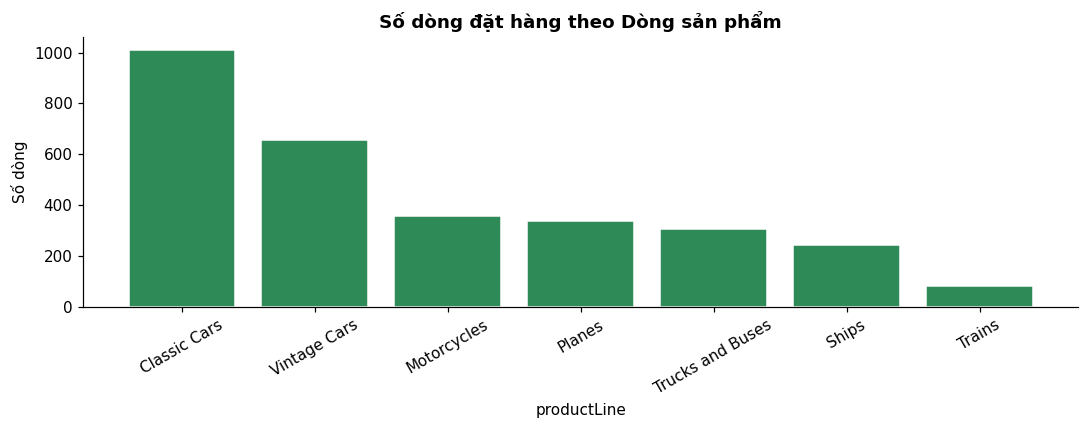

productLine
Classic Cars        1010
Vintage Cars         657
Motorcycles          359
Planes               336
Trucks and Buses     308
Ships                245
Trains                81


In [16]:
# Dòng sản phẩm
plot_countbar(df, "productLine",
              title="Số dòng đặt hàng theo Dòng sản phẩm",
              color="seagreen")

print(df["productLine"].value_counts().to_string())

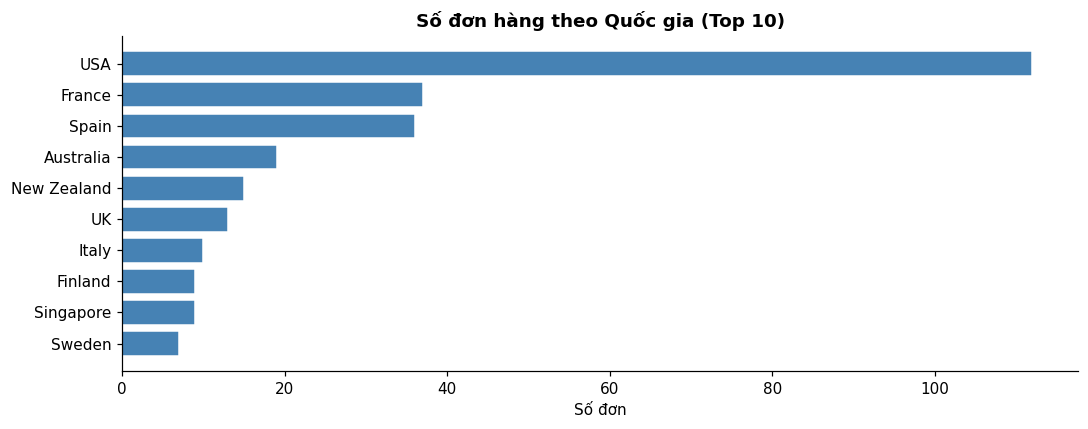

customerCountry
USA            112
France          37
Spain           36
Australia       19
New Zealand     15
UK              13
Italy           10
Singapore        9
Finland          9
Sweden           7


In [17]:
# Quốc gia khách hàng (Top 10)
top10_country = (df.drop_duplicates("orderNumber")
                   .groupby("customerCountry")["orderNumber"]
                   .count()
                   .sort_values()
                   .tail(10))

fig, ax = plt.subplots()
ax.barh(top10_country.index.astype(str), top10_country.values,
        color="steelblue", edgecolor="white")
ax.set_title("Số đơn hàng theo Quốc gia (Top 10)")
ax.set_xlabel("Số đơn")
plt.tight_layout()
plt.show()

print(top10_country.sort_values(ascending=False).to_string())

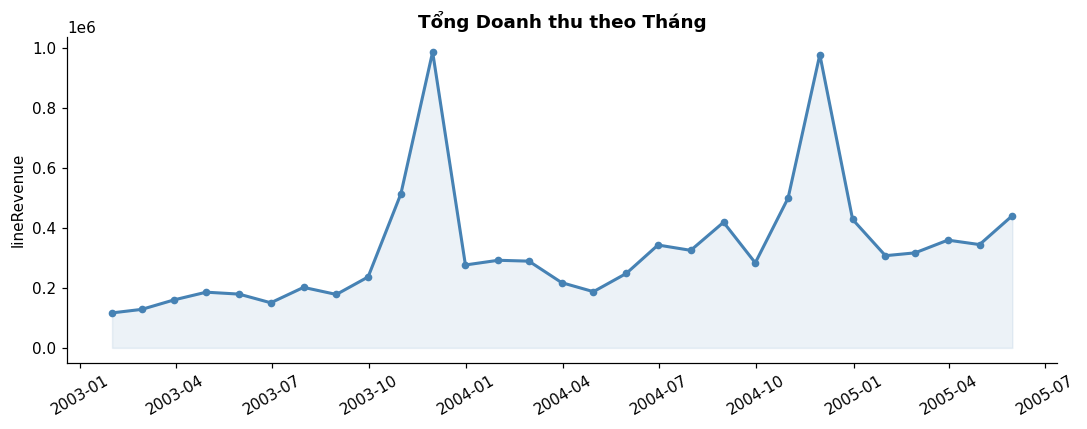

In [19]:
# ================================================================
# CELL 15 — XU HƯỚNG THỜI GIAN
# ================================================================

# Thêm cột thời gian
df["year"]    = df["orderDate"].dt.year
df["month"]   = df["orderDate"].dt.month
df["quarter"] = df["orderDate"].dt.quarter

# Doanh thu theo tháng
plot_line(df, "orderDate", "lineRevenue",
          freq="ME", agg="sum",
          title="Tổng Doanh thu theo Tháng")

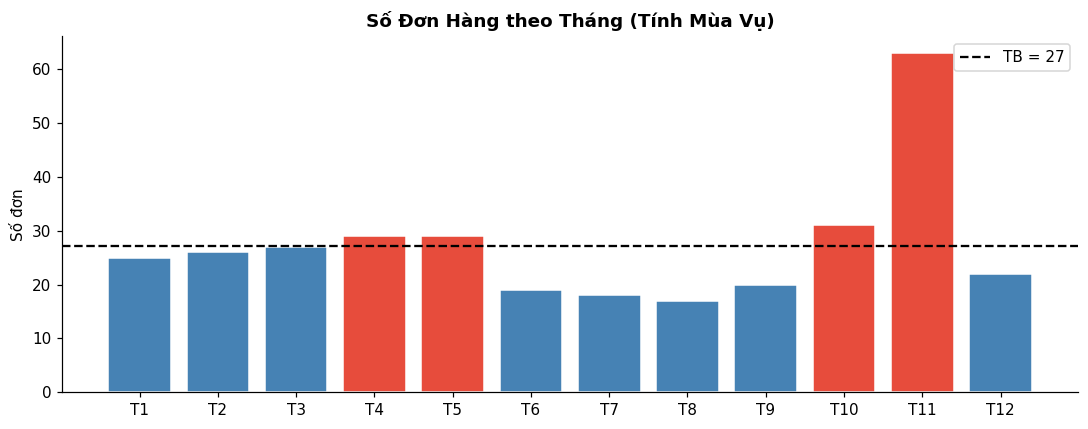

Tháng có nhiều đơn nhất:
month
11    63
10    31
4     29

Tháng có ít đơn nhất:
month
8    17
7    18
6    19


In [20]:
# Số đơn theo tháng trong năm (seasonality)
monthly_orders = (df.drop_duplicates("orderNumber")
                    .groupby("month")["orderNumber"]
                    .count())

fig, ax = plt.subplots()
avg = monthly_orders.mean()
colors = ["#e74c3c" if v >= avg else "steelblue"
          for v in monthly_orders.values]
ax.bar(monthly_orders.index, monthly_orders.values,
       color=colors, edgecolor="white")
ax.axhline(avg, color="black", lw=1.5, linestyle="--",
           label=f"TB = {avg:.0f}")
ax.set_xticks(range(1, 13))
ax.set_xticklabels(["T1","T2","T3","T4","T5","T6",
                    "T7","T8","T9","T10","T11","T12"])
ax.set_title("Số Đơn Hàng theo Tháng (Tính Mùa Vụ)")
ax.set_ylabel("Số đơn")
ax.legend()
plt.tight_layout()
plt.show()

print("Tháng có nhiều đơn nhất:")
print(monthly_orders.sort_values(ascending=False).head(3).to_string())
print("\nTháng có ít đơn nhất:")
print(monthly_orders.sort_values().head(3).to_string())

## **Buổi 2**

In [21]:
# ================================================================
# CELL 16 — GROUPBY: KPI THEO DÒNG SẢN PHẨM
# ================================================================

pl_kpi = (
    df.groupby("productLine")
      .agg(
          TotalRevenue    = ("lineRevenue",     "sum"),
          AvgRevenue      = ("lineRevenue",     "mean"),
          TotalQty        = ("quantityOrdered", "sum"),
          UniqueOrders    = ("orderNumber",     "nunique"),
          UniqueCustomers = ("customerNumber",  "nunique"),
      )
      .round(0)
      .sort_values("TotalRevenue", ascending=False)
      .reset_index()
)

pl_kpi["Revenue%"] = (pl_kpi["TotalRevenue"]
                       / pl_kpi["TotalRevenue"].sum() * 100).round(1)

print(pl_kpi.to_string(index=False))

     productLine  TotalRevenue  AvgRevenue  TotalQty  UniqueOrders  UniqueCustomers  Revenue%
    Classic Cars  3,853,922.00    3,816.00     35582           209               94     40.10
    Vintage Cars  1,797,560.00    2,736.00     22933           187               90     18.70
     Motorcycles  1,121,426.00    3,124.00     12778            79               55     11.70
Trucks and Buses  1,024,114.00    3,325.00     11001            75               50     10.70
          Planes    954,638.00    2,841.00     11872            66               52      9.90
           Ships    663,998.00    2,710.00      8532            68               51      6.90
          Trains    188,533.00    2,328.00      2818            47               36      2.00


In [22]:
# ================================================================
# CELL 17 — GROUPBY: KPI THEO NHÂN VIÊN KINH DOANH
# ================================================================

rep_kpi = (
    df.groupby("salesRep")
      .agg(
          TotalRevenue    = ("lineRevenue",     "sum"),
          UniqueCustomers = ("customerNumber",  "nunique"),
          UniqueOrders    = ("orderNumber",     "nunique"),
          AvgOrderRevenue = ("lineRevenue",     "mean"),
      )
      .round(0)
      .sort_values("TotalRevenue", ascending=False)
      .reset_index()
)

print(rep_kpi.to_string(index=False))

        salesRep  TotalRevenue  UniqueCustomers  UniqueOrders  AvgOrderRevenue
Gerard Hernandez  1,258,578.00                7            43         3,178.00
 Leslie Jennings  1,081,530.00                6            34         3,267.00
 Pamela Castillo    868,221.00               10            31         3,192.00
      Larry Bott    732,097.00                8            22         3,102.00
     Barry Jones    704,854.00                9            25         3,204.00
   George Vanauf    669,377.00                8            22         3,172.00
     Peter Marsh    584,594.00                5            19         3,160.00
     Loui Bondur    569,486.00                6            20         3,217.00
     Andy Fixter    562,583.00                5            19         3,041.00
 Steve Patterson    505,875.00                6            18         3,328.00
  Foon Yue Tseng    488,213.00                6            17         3,438.00
      Mami Nishi    457,110.00                5     

In [23]:
# ================================================================
# CELL 18 — GROUPBY: DOANH THU THEO NĂM × DÒNG SẢN PHẨM
# ================================================================

year_pl = (
    df.groupby(["year", "productLine"])["lineRevenue"]
      .sum()
      .unstack("productLine")
      .fillna(0)
      .round(0)
)

print("=== Doanh thu theo Năm × Dòng SP (USD) ===")
print(year_pl.to_string())
print()

# Tăng trưởng 2003 → 2004
growth = ((year_pl.loc[2004] - year_pl.loc[2003])
           / year_pl.loc[2003] * 100).round(1)
print("=== Tăng trưởng 2003→2004 (%) ===")
print(growth.sort_values(ascending=False).to_string())

=== Doanh thu theo Năm × Dòng SP (USD) ===
productLine  Classic Cars  Motorcycles     Planes      Ships    Trains  Trucks and Buses  Vintage Cars
year                                                                                                  
2003         1,374,832.00   348,909.00 309,784.00 222,182.00 65,822.00        376,657.00    619,162.00
2004         1,763,137.00   527,244.00 471,971.00 337,326.00 96,286.00        465,390.00    854,552.00
2005           715,954.00   245,273.00 172,882.00 104,490.00 26,425.00        182,066.00    323,846.00

=== Tăng trưởng 2003→2004 (%) ===
productLine
Planes             52.40
Ships              51.80
Motorcycles        51.10
Trains             46.30
Vintage Cars       38.00
Classic Cars       28.20
Trucks and Buses   23.60


In [24]:
# ================================================================
# CELL 19 — PIVOT TABLE
# ================================================================

pivot = pd.pivot_table(
    df,
    values      = "lineRevenue",
    index       = "year",
    columns     = "productLine",
    aggfunc     = "sum",
    fill_value  = 0,
    margins     = True,
    margins_name= "TỔNG",
)

print("=== PIVOT: Doanh Thu (K USD) ===")
print((pivot / 1e3).round(1).to_string())

=== PIVOT: Doanh Thu (K USD) ===
productLine  Classic Cars  Motorcycles  Planes  Ships  Trains  Trucks and Buses  Vintage Cars     TỔNG
year                                                                                                  
2003             1,374.80       348.90  309.80 222.20   65.80            376.70        619.20 3,317.30
2004             1,763.10       527.20  472.00 337.30   96.30            465.40        854.60 4,515.90
2005               716.00       245.30  172.90 104.50   26.40            182.10        323.80 1,770.90
TỔNG             3,853.90     1,121.40  954.60 664.00  188.50          1,024.10      1,797.60 9,604.20


In [25]:
# ================================================================
# CELL 20 — CROSSTAB
# ================================================================

# Tạo nhóm doanh thu
df["revenueGroup"] = pd.cut(
    df["lineRevenue"],
    bins   = [0, 1000, 3000, 6000, float("inf")],
    labels = ["Thấp(<1K)", "TB(1-3K)", "Cao(3-6K)", "VIP(>6K)"]
)

# Crosstab: % phân bổ nhóm DT trong từng dòng SP
ct = pd.crosstab(
    df["productLine"],
    df["revenueGroup"],
    normalize="index"
) * 100

print("=== CROSSTAB: % Đơn theo Nhóm Doanh Thu ===")
print("(Mỗi hàng = 100%)")
print(ct.round(1).to_string())

=== CROSSTAB: % Đơn theo Nhóm Doanh Thu ===
(Mỗi hàng = 100%)
revenueGroup      Thấp(<1K)  TB(1-3K)  Cao(3-6K)  VIP(>6K)
productLine                                               
Classic Cars           2.30     36.60      47.70     13.40
Motorcycles            2.20     53.50      38.20      6.10
Planes                 1.50     61.90      33.60      3.00
Ships                  0.40     64.90      34.70      0.00
Trains                 2.50     81.50      16.00      0.00
Trucks and Buses       1.30     45.50      51.60      1.60
Vintage Cars           5.80     56.30      34.60      3.30


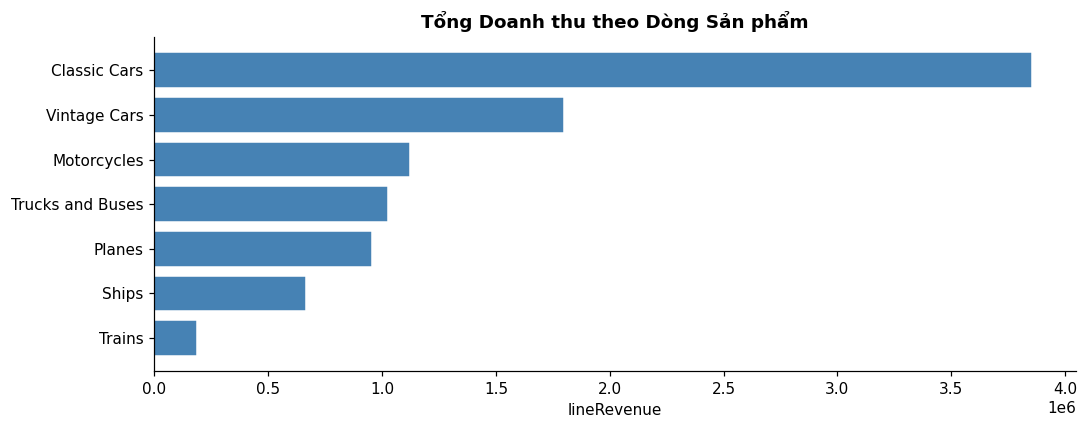

In [26]:
# ================================================================
# CELL 21 — SO SÁNH DOANH THU THEO NHÓM
# ================================================================

# Doanh thu theo dòng SP
plot_bar(df, "productLine", "lineRevenue",
         title="Tổng Doanh thu theo Dòng Sản phẩm")

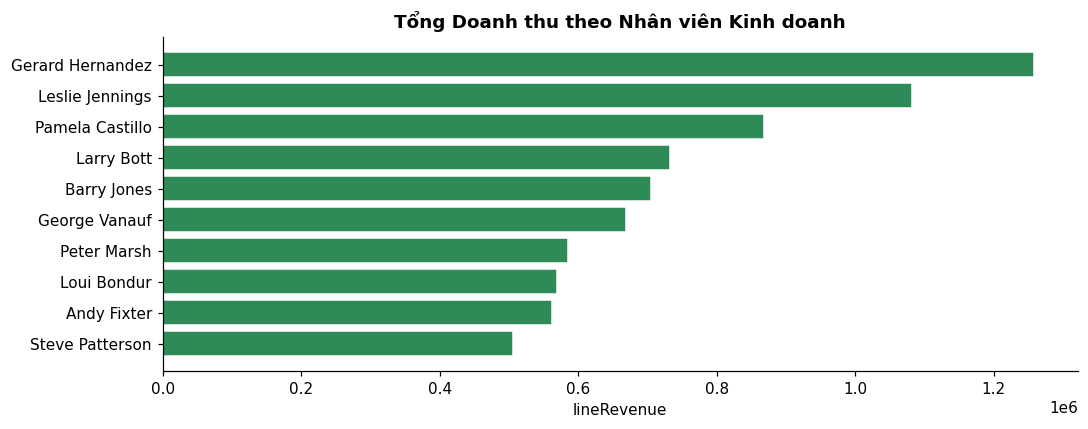

In [27]:
# Doanh thu theo nhân viên
plot_bar(df, "salesRep", "lineRevenue",
         title="Tổng Doanh thu theo Nhân viên Kinh doanh",
         color="seagreen")

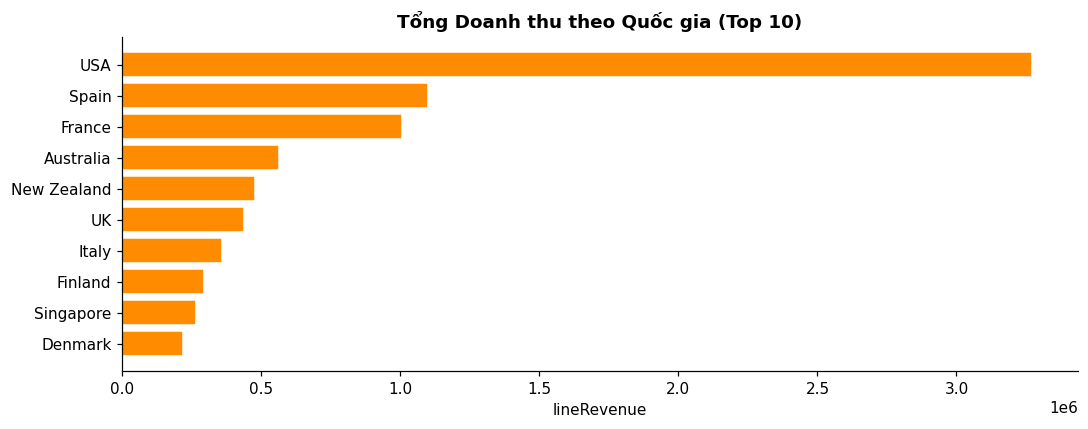

In [28]:
# Doanh thu theo quốc gia
plot_bar(df, "customerCountry", "lineRevenue",
         top_n=10,
         title="Tổng Doanh thu theo Quốc gia (Top 10)",
         color="darkorange")

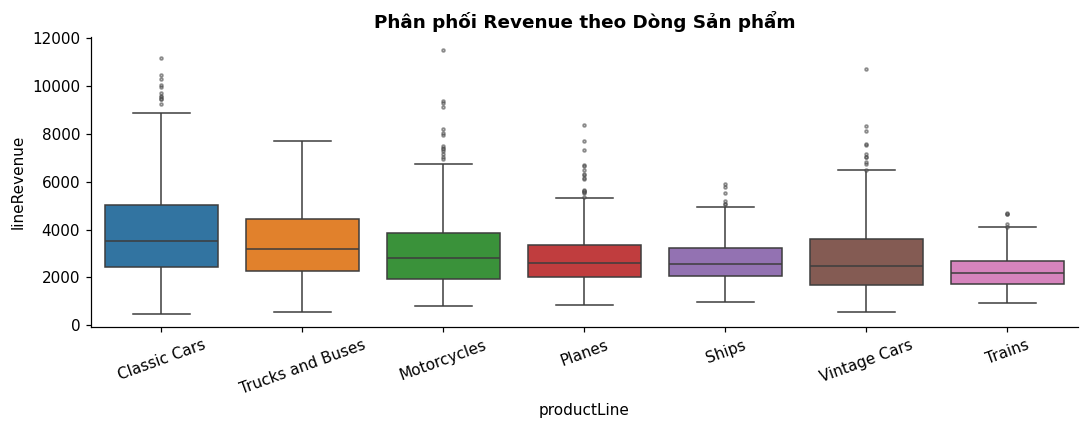

In [29]:
# ================================================================
# CELL 22 — BOXPLOT PHÂN PHỐI THEO NHÓM
# ================================================================

# Revenue theo dòng SP
plot_boxplot(df, "lineRevenue", "productLine",
             title="Phân phối Revenue theo Dòng Sản phẩm")

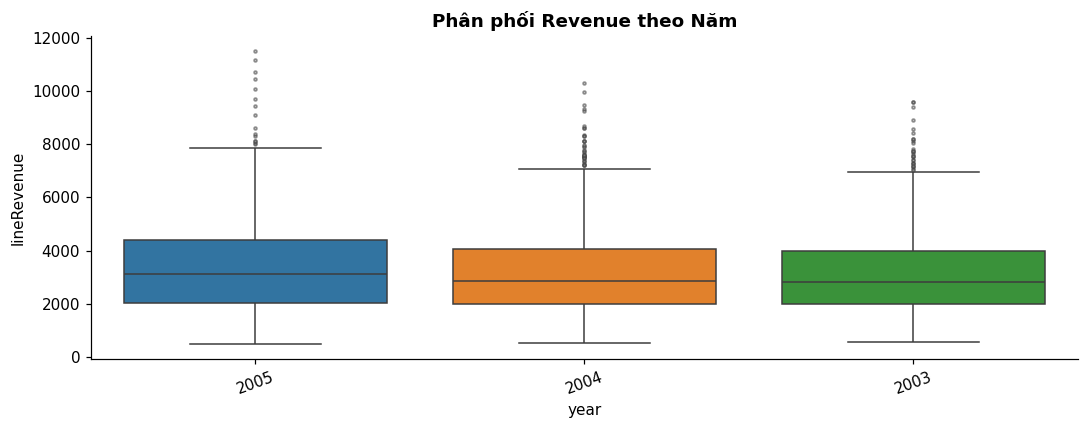

In [30]:
# Revenue theo năm
plot_boxplot(df, "lineRevenue", "year",
             title="Phân phối Revenue theo Năm")

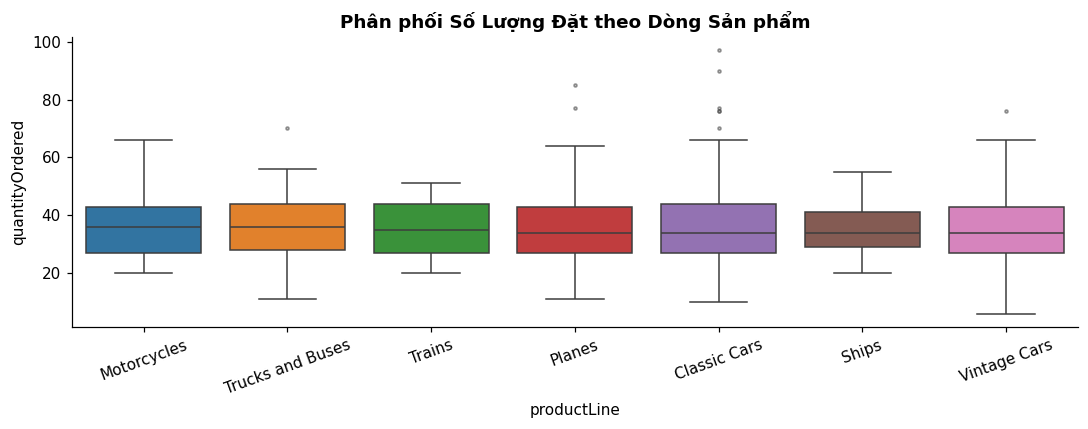

In [31]:
# Số lượng đặt theo dòng SP
plot_boxplot(df, "quantityOrdered", "productLine",
             title="Phân phối Số Lượng Đặt theo Dòng Sản phẩm")

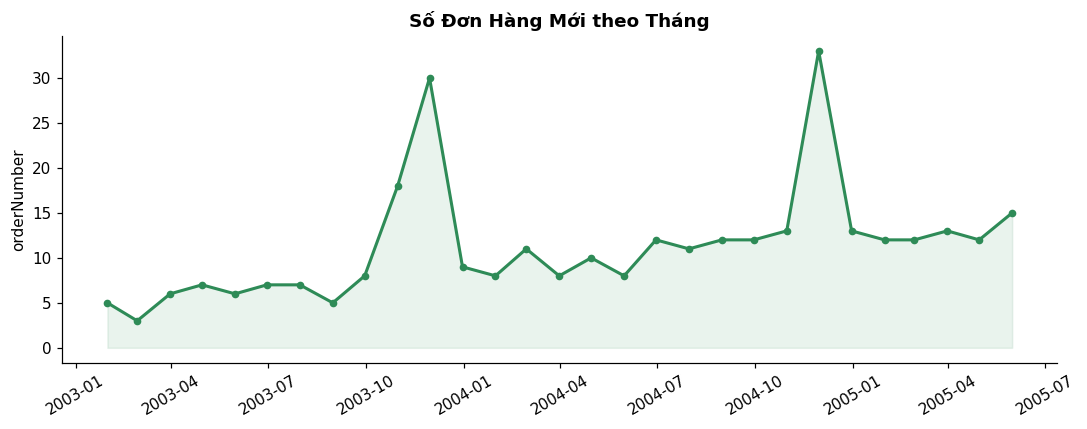

In [33]:
# ================================================================
# CELL 23 — XU HƯỚNG THEO THỜI GIAN
# ================================================================

# Số đơn hàng mới theo tháng
plot_line(df.drop_duplicates("orderNumber"),
          "orderDate", "orderNumber",
          freq="ME", agg="count",
          title="Số Đơn Hàng Mới theo Tháng",
          color="seagreen")

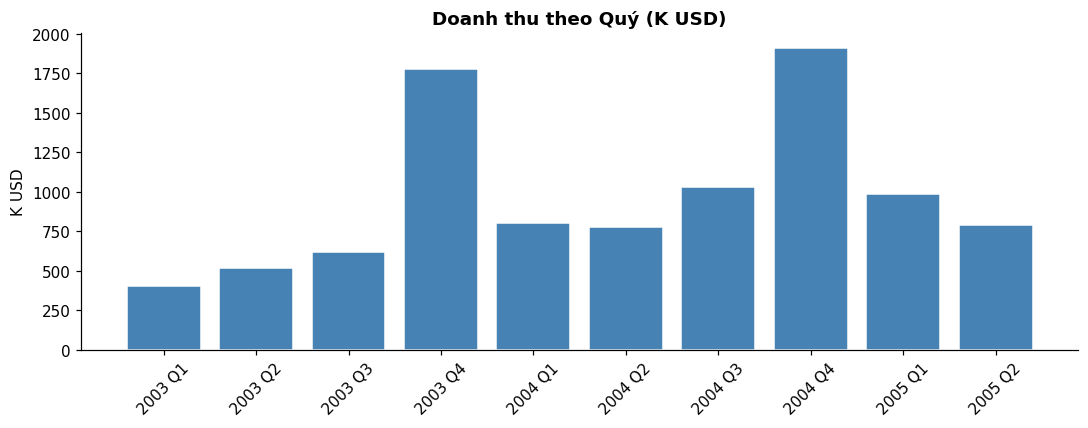

  label  lineRevenue
2003 Q1   405,613.56
2003 Q2   515,754.91
2003 Q3   616,895.31
2003 Q4 1,779,084.62
2004 Q1   799,579.31
2004 Q2   779,271.81
2004 Q3 1,028,690.38
2004 Q4 1,908,364.00
2005 Q1   984,641.12
2005 Q2   786,295.56


In [34]:
# Doanh thu theo quý
quarterly = (
    df.groupby(["year", "quarter"])["lineRevenue"]
      .sum()
      .reset_index()
)
quarterly["label"] = (quarterly["year"].astype(str)
                       + " Q" + quarterly["quarter"].astype(str))

fig, ax = plt.subplots()
ax.bar(quarterly["label"], quarterly["lineRevenue"] / 1e3,
       color="steelblue", edgecolor="white")
ax.set_title("Doanh thu theo Quý (K USD)")
ax.set_ylabel("K USD")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

print(quarterly[["label","lineRevenue"]].to_string(index=False))

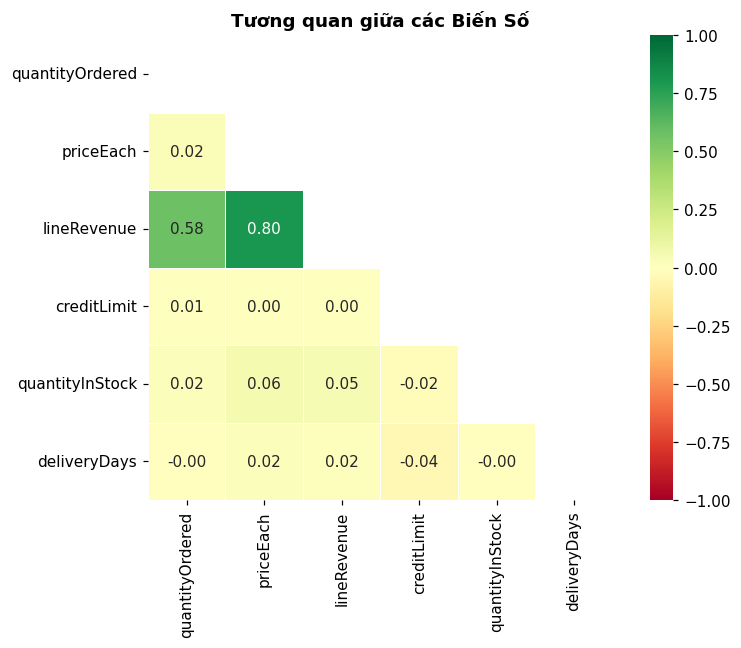

In [35]:
# ================================================================
# CELL 24 — HEATMAP TƯƠNG QUAN
# ================================================================

plot_heatmap_corr(
    df,
    cols=["quantityOrdered", "priceEach", "lineRevenue",
          "creditLimit", "quantityInStock", "deliveryDays"],
    title="Tương quan giữa các Biến Số"
)

In [36]:
# ================================================================
# CELL 25 — HIỂU IQR RULE BẰNG VÍ DỤ ĐƠN GIẢN
# ================================================================

print("=== IQR RULE — Cách hoạt động ===")
print()

col  = "lineRevenue"
data = df[col].dropna()

Q1  = data.quantile(0.25)
Q3  = data.quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

n_low  = (data < lower).sum()
n_high = (data > upper).sum()
n_out  = n_low + n_high

print(f"Cột: {col}")
print(f"  Q1 (25%)   = {Q1:>10,.1f}")
print(f"  Q3 (75%)   = {Q3:>10,.1f}")
print(f"  IQR        = {IQR:>10,.1f}  (= Q3 - Q1)")
print(f"  Lower Bound= {lower:>10,.1f}  (= Q1 - 1.5 × IQR)")
print(f"  Upper Bound= {upper:>10,.1f}  (= Q3 + 1.5 × IQR)")
print()
print(f"  Outlier thấp (< Lower): {n_low:>4} dòng")
print(f"  Outlier cao (> Upper) : {n_high:>4} dòng")
print(f"  Tổng outlier          : {n_out:>4} dòng ({n_out/len(data)*100:.1f}%)")

=== IQR RULE — Cách hoạt động ===

Cột: lineRevenue
  Q1 (25%)   =    1,990.3
  Q3 (75%)   =    4,093.9
  IQR        =    2,103.6  (= Q3 - Q1)
  Lower Bound=   -1,165.2  (= Q1 - 1.5 × IQR)
  Upper Bound=    7,249.4  (= Q3 + 1.5 × IQR)

  Outlier thấp (< Lower):    0 dòng
  Outlier cao (> Upper) :   76 dòng
  Tổng outlier          :   76 dòng (2.5%)


In [37]:
# ================================================================
# CELL 26 — HÀM PHÁT HIỆN OUTLIER (tái sử dụng)
# ================================================================

# ── HÀM TÁI SỬ DỤNG ────────────────────────────────────────────
def detect_outliers(series: pd.Series,
                    multiplier: float = 1.5) -> dict:
    """
    Phát hiện outlier bằng IQR Rule.
    Trả về dict chứa bounds và mask outlier.

    Parameters
    ----------
    series     : Cột dữ liệu số cần kiểm tra
    multiplier : Hệ số IQR (1.5 = chuẩn, 3.0 = rộng hơn)

    Returns
    -------
    dict: lower, upper, mask, n_out, pct_out
    """
    Q1  = series.quantile(0.25)
    Q3  = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - multiplier * IQR
    upper = Q3 + multiplier * IQR
    mask  = (series < lower) | (series > upper)
    return {
        "lower" : lower,
        "upper" : upper,
        "mask"  : mask,
        "n_out" : int(mask.sum()),
        "pct_out": round(mask.mean() * 100, 1),
    }


def outlier_summary(df: pd.DataFrame, cols: list) -> None:
    """
    In tóm tắt outlier cho nhiều cột.
    Tái sử dụng: Truyền vào list cột số cần kiểm tra.
    """
    print(f"{'Cột':<20} {'Lower':>10} {'Upper':>10} "
          f"{'Số outlier':>12} {'Tỷ lệ':>8}")
    print("-" * 65)
    for col in cols:
        if col not in df.columns:
            continue
        r = detect_outliers(df[col].dropna())
        print(f"{col:<20} {r['lower']:>10,.1f} {r['upper']:>10,.1f} "
              f"{r['n_out']:>12,} {r['pct_out']:>7.1f}%")


cols_to_check = ["lineRevenue", "quantityOrdered",
                 "priceEach", "creditLimit", "deliveryDays"]

print("=== TÓM TẮT OUTLIER ===")
outlier_summary(df, cols_to_check)

=== TÓM TẮT OUTLIER ===
Cột                       Lower      Upper   Số outlier    Tỷ lệ
-----------------------------------------------------------------
lineRevenue            -1,165.2    7,249.4           76     2.5%
quantityOrdered             3.0       67.0           10     0.3%
priceEach                 -17.0      193.6           29     1.0%
creditLimit            14,850.0  182,450.0          442    14.8%
deliveryDays               -2.5        9.5           18     0.6%


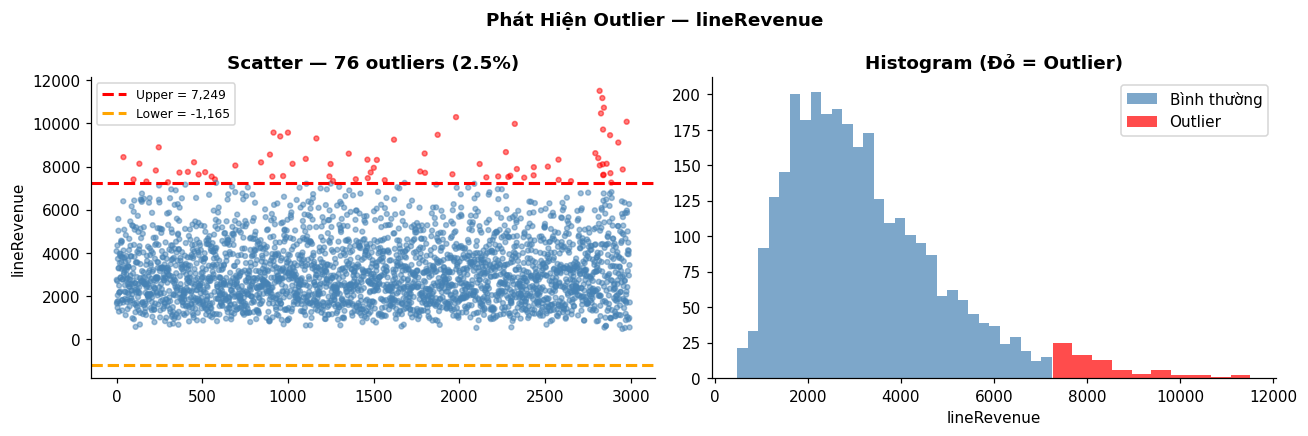

In [38]:
# ================================================================
# CELL 27 — TRỰC QUAN HÓA OUTLIER
# ================================================================

def plot_outlier(df: pd.DataFrame, col: str, title: str = None):
    """
    Vẽ scatter plot với điểm đỏ = outlier.
    Kết hợp với histogram để thấy rõ outlier.
    """
    data = df[col].dropna().reset_index(drop=True)
    r    = detect_outliers(data)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Scatter: thấy vị trí outlier
    colors = ["red" if v else "steelblue" for v in r["mask"].values]
    axes[0].scatter(range(len(data)), data.values,
                    c=colors, s=10, alpha=0.5)
    axes[0].axhline(r["upper"], color="red",    lw=2, ls="--",
                    label=f"Upper = {r['upper']:,.0f}")
    axes[0].axhline(r["lower"], color="orange", lw=2, ls="--",
                    label=f"Lower = {r['lower']:,.0f}")
    axes[0].set_title(f"Scatter — {r['n_out']} outliers ({r['pct_out']}%)")
    axes[0].set_ylabel(col)
    axes[0].legend(fontsize=8)

    # Histogram: thấy phân phối và ngưỡng
    axes[1].hist(data[~r["mask"]], bins=30,
                 color="steelblue", alpha=0.7, label="Bình thường")
    axes[1].hist(data[r["mask"]],  bins=10,
                 color="red",      alpha=0.7, label="Outlier")
    axes[1].set_title("Histogram (Đỏ = Outlier)")
    axes[1].set_xlabel(col)
    axes[1].legend()

    plt.suptitle(title or col, fontweight="bold")
    plt.tight_layout()
    plt.show()


# Áp dụng
plot_outlier(df, "lineRevenue",
             title="Phát Hiện Outlier — lineRevenue")

In [39]:
# ================================================================
# CELL 28 — XEM CHI TIẾT OUTLIER THEO NGỮ CẢNH
# ================================================================

print("=== OUTLIER lineRevenue > Upper Bound ===")
r = detect_outliers(df["lineRevenue"].dropna())

outlier_rows = (
    df[r["mask"]]
    .sort_values("lineRevenue", ascending=False)
    [["orderNumber","customerName","productName",
      "productLine","quantityOrdered","priceEach","lineRevenue"]]
    .head(10)
)
print(outlier_rows.to_string(index=False))

print()
print("--- Phân bổ outlier theo productLine ---")
print(df[r["mask"]]["productLine"].value_counts().to_string())

=== OUTLIER lineRevenue > Upper Bound ===
 orderNumber                   customerName                          productName  productLine  quantityOrdered  priceEach  lineRevenue
       10403          UK Collectables, Ltd. 2003 Harley-Davidson Eagle Drag Bike  Motorcycles               66     174.29    11,503.14
       10405                    Mini Caravy                   1969 Dodge Charger Classic Cars               97     115.16    11,170.52
       10407      The Sharp Gifts Warehouse             1917 Grand Touring Sedan Vintage Cars               76     141.10    10,723.60
       10404     Down Under Souveniers, Inc                    1968 Ford Mustang Classic Cars               64     163.44    10,460.16
       10312   Mini Gifts Distributors Ltd.             1952 Alpine Renault 1300 Classic Cars               48     214.30    10,286.40
       10424         Euro+ Shopping Channel             1952 Alpine Renault 1300 Classic Cars               50     201.44    10,072.00
       10348 

In [40]:
# ================================================================
# CELL 29 — CAPPING OUTLIER (đơn giản, dễ hiểu)
# ================================================================

"""
CAPPING = Kéo giá trị outlier về ngưỡng Upper/Lower Bound
  - Giá trị > Upper → Gán bằng Upper
  - Giá trị < Lower → Gán bằng Lower
  - Số dòng KHÔNG thay đổi (không xóa dòng nào)
"""

# ── HÀM TÁI SỬ DỤNG ────────────────────────────────────────────
def cap_outliers(df: pd.DataFrame,
                 cols: list,
                 multiplier: float = 1.5) -> pd.DataFrame:
    """
    Capping (Winsorization) nhiều cột.
    Kéo outlier về ngưỡng IQR thay vì xóa.

    Parameters
    ----------
    df         : DataFrame gốc
    cols       : List cột cần cap
    multiplier : Hệ số IQR (mặc định 1.5)

    Returns
    -------
    DataFrame đã cap (bản copy, không sửa df gốc)
    """
    out = df.copy()
    print(f"{'Cột':<20} {'Max trước':>12} {'Max sau':>12} {'Số thay đổi':>12}")
    print("-" * 60)
    for col in cols:
        if col not in out.columns:
            continue
        r     = detect_outliers(out[col].dropna(), multiplier)
        lb    = max(0, r["lower"])   # Không cho xuống dưới 0
        ub    = r["upper"]
        n     = ((out[col] < lb) | (out[col] > ub)).sum()
        b_max = out[col].max()
        out[col] = out[col].clip(lower=lb, upper=ub)
        a_max = out[col].max()
        print(f"{col:<20} {b_max:>12,.1f} {a_max:>12,.1f} {n:>12,}")
    print()
    print(f"Số dòng trước: {len(df):,}")
    print(f"Số dòng sau  : {len(out):,}  ← Không thay đổi ✅")
    return out


# Áp dụng capping
df_capped = cap_outliers(
    df,
    cols=["lineRevenue", "quantityOrdered", "priceEach"]
)

Cột                     Max trước      Max sau  Số thay đổi
------------------------------------------------------------
lineRevenue              11,503.1      7,249.4           76
quantityOrdered              97.0         67.0           10
priceEach                   214.3        193.6           29

Số dòng trước: 2,996
Số dòng sau  : 2,996  ← Không thay đổi ✅


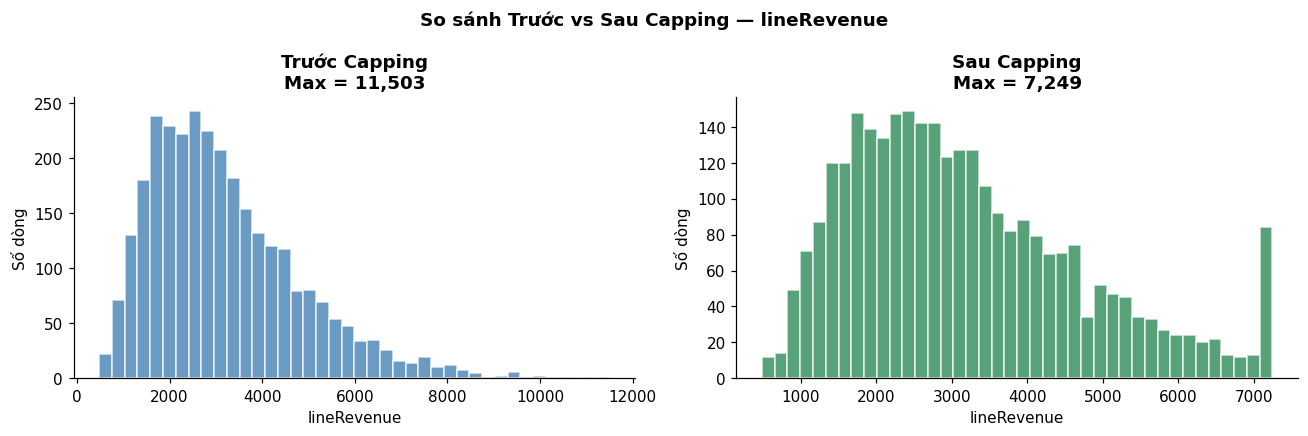

=== SO SÁNH THỐNG KÊ ===
  Trước: Mean=   3,206 | Median=   2,880 | Max=  11,503
  Sau  : Mean=   3,179 | Median=   2,880 | Max=   7,249


In [41]:
# ================================================================
# CELL 30 — SO SÁNH TRƯỚC VÀ SAU CAPPING
# ================================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Trước
axes[0].hist(df["lineRevenue"].dropna(), bins=40,
             color="steelblue", edgecolor="white", alpha=0.8)
axes[0].set_title(f"Trước Capping\nMax = {df['lineRevenue'].max():,.0f}")
axes[0].set_xlabel("lineRevenue")
axes[0].set_ylabel("Số dòng")

# Sau
axes[1].hist(df_capped["lineRevenue"].dropna(), bins=40,
             color="seagreen", edgecolor="white", alpha=0.8)
axes[1].set_title(f"Sau Capping\nMax = {df_capped['lineRevenue'].max():,.0f}")
axes[1].set_xlabel("lineRevenue")
axes[1].set_ylabel("Số dòng")

plt.suptitle("So sánh Trước vs Sau Capping — lineRevenue",
             fontweight="bold")
plt.tight_layout()
plt.show()

# So sánh thống kê
print("=== SO SÁNH THỐNG KÊ ===")
for label, data in [("Trước", df["lineRevenue"]),
                     ("Sau  ", df_capped["lineRevenue"])]:
    print(f"  {label}: Mean={data.mean():>8,.0f} | "
          f"Median={data.median():>8,.0f} | "
          f"Max={data.max():>8,.0f}")